# 🤖 NewsBot Intelligence System
## ITAI 2373 - Mid-Term Group Project Template

**Team Members:** [Cameroun White, Justin Davis, Joncarlo Esquivel, Cloris Banks]
**Date:** [Nov 1,2025]
**GitHub Repository:** [Add your repo URL here]

---

## 🎯 Project Overview

Welcome to your NewsBot Intelligence System! This notebook will guide you through building a comprehensive NLP system that:

- 📰 **Processes** news articles with advanced text cleaning
- 🏷️ **Classifies** articles into categories (Politics, Sports, Technology, Business, Entertainment, Health)
- 🔍 **Extracts** named entities (people, organizations, locations, dates, money)
- 😊 **Analyzes** sentiment and emotional tone
- 📊 **Generates** insights for business intelligence

### 📚 Module Integration Checklist
- [ ] **Module 1:** NLP applications and real-world context
- [ ] **Module 2:** Text preprocessing pipeline
- [ ] **Module 3:** TF-IDF feature extraction
- [ ] **Module 4:** POS tagging analysis
- [ ] **Module 5:** Syntax parsing and semantic analysis
- [ ] **Module 6:** Sentiment and emotion analysis
- [ ] **Module 7:** Text classification system
- [ ] **Module 8:** Named Entity Recognition

---

## 📦 Setup and Installation

Let's start by installing and importing all the libraries we'll need for our NewsBot system.

In [1]:
# Install required packages (run this cell first!)
!pip install spacy scikit-learn nltk pandas matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 108.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ All packages installed successfully!


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [2]:
%pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.5 MB/s eta 0:00:00


In [3]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


In [18]:
# ✅ Manual ZIP Upload and Extract Fix
from google.colab import files
import zipfile, os, pandas as pd

print("⬆️ Upload your BBC ZIP file (e.g. BBC News Train.csv.zip or learn-ai-bbc.zip)")
uploaded = files.upload()  # Choose your ZIP file

# Automatically grab the uploaded filename
zip_name = list(uploaded.keys())[0]

# Extract it
extract_path = "bbc_data"
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Confirm contents
print("✅ Files extracted successfully!")
print("📂 Contents:", os.listdir(extract_path))

# Load the training data
csv_candidates = [f for f in os.listdir(extract_path) if f.lower().endswith('.csv')]
print("📄 CSVs found:", csv_candidates)

# Use the first CSV that looks like the train set
csv_to_use = [f for f in csv_candidates if 'train' in f.lower()]
if csv_to_use:
    train_csv = os.path.join(extract_path, csv_to_use[0])
else:
    train_csv = os.path.join(extract_path, csv_candidates[0])

df = pd.read_csv(train_csv)
print("✅ Dataset loaded successfully!")
print("Total articles:", len(df))
display(df.head())


⬆️ Upload your BBC ZIP file (e.g. BBC News Train.csv.zip or learn-ai-bbc.zip)


Saving learn-ai-bbc.zip to learn-ai-bbc (3).zip
✅ Files extracted successfully!
📂 Contents: ['BBC News Sample Solution.csv', 'BBC News Train.csv', 'BBC News Test.csv']
📄 CSVs found: ['BBC News Sample Solution.csv', 'BBC News Train.csv', 'BBC News Test.csv']
✅ Dataset loaded successfully!
Total articles: 1490


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


## 📊 Data Loading and Exploration

### 🎯 Module 1: Understanding Our NLP Application

Before we dive into the technical implementation, let's understand the real-world context of our NewsBot Intelligence System. This system addresses several business needs:

1. **Media Monitoring:** Automatically categorize and track news coverage
2. **Business Intelligence:** Extract key entities and sentiment trends
3. **Content Management:** Organize large volumes of news content
4. **Market Research:** Understand public sentiment about topics and entities

**💡 Discussion Question:** What other real-world applications can you think of for this type of system? Consider different industries and use cases.

In [19]:
import pandas as pd

# Load the BBC News Train dataset
df = pd.read_csv('bbc_data/BBC News Train.csv')

# Quick overview
print("📊 Dataset loaded successfully!")
print(f"📈 Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")
print(f"📈 Total articles: {len(df)}")

# Display first few rows
df.head()


📊 Dataset loaded successfully!
📈 Shape: (1490, 3)
📋 Columns: ['ArticleId', 'Text', 'Category']
📈 Total articles: 1490


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


📊 DATASET OVERVIEW
Total articles: 1490
Unique categories: 5
Categories: ['business', 'tech', 'politics', 'sport', 'entertainment']

📈 CATEGORY DISTRIBUTION
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


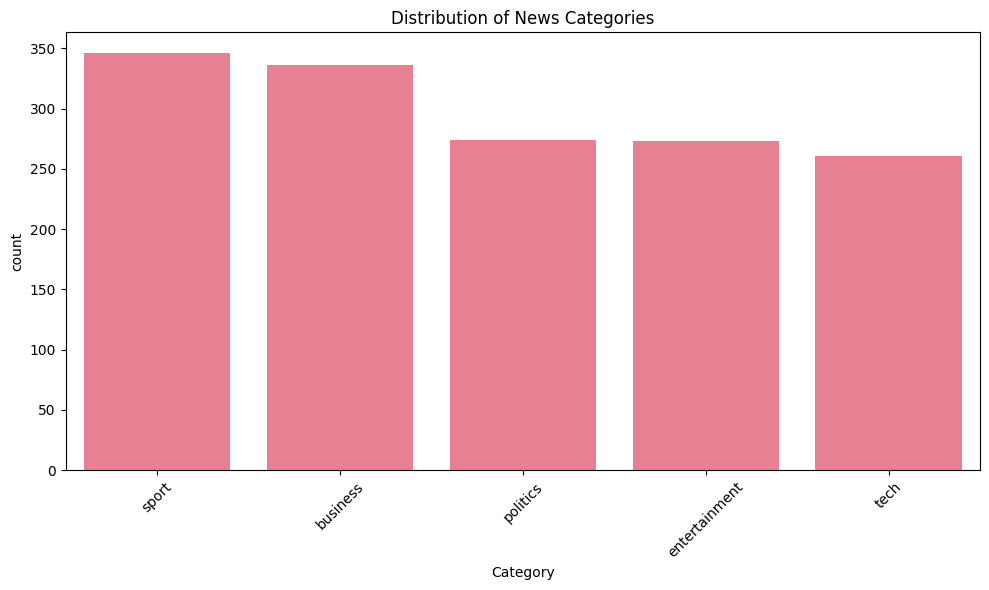

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic dataset exploration
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total articles: {len(df)}")
print(f"Unique categories: {df['Category'].nunique()}")
print(f"Categories: {df['Category'].unique().tolist()}")
# print(f"Date range: {df['date'].min()} to {df['date'].max()}") # Date column does not exist
# print(f"Unique sources: {df['source'].nunique()}") # Source column does not exist

print("\n📈 CATEGORY DISTRIBUTION")
print("=" * 50)
category_counts = df['Category'].value_counts()
print(category_counts)

# Visualize category distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Category', order=category_counts.index)
plt.title('Distribution of News Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 💡 STUDENT TASK: Add your own exploratory analysis here
# - Check for missing values
# - Analyze text length distribution
# - Examine source distribution
# - Look for any data quality issues

## 🧹 Text Preprocessing Pipeline

### 🎯 Module 2: Advanced Text Preprocessing

Now we'll implement a comprehensive text preprocessing pipeline that cleans and normalizes our news articles. This is crucial for all downstream NLP tasks.

**Key Preprocessing Steps:**
1. **Text Cleaning:** Remove HTML, URLs, special characters
2. **Tokenization:** Split text into individual words
3. **Normalization:** Convert to lowercase, handle contractions
4. **Stop Word Removal:** Remove common words that don't carry meaning
5. **Lemmatization:** Reduce words to their base form

**💡 Think About:** Why is preprocessing so important? What happens if we skip these steps?

In [21]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Comprehensive text cleaning function

    💡 TIP: This function should handle:
    - HTML tags and entities
    - URLs and email addresses
    - Special characters and numbers
    - Extra whitespace
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Complete preprocessing pipeline

    💡 TIP: This function should:
    - Clean the text
    - Tokenize into words
    - Remove stop words (optional)
    - Lemmatize words (optional)
    - Return processed text
    """
    # Clean text
    text = clean_text(text)

    if not text:
        return ""

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words if requested
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize if requested
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Filter out very short words
    tokens = [token for token in tokens if len(token) > 2]

    return ' '.join(tokens)

# Test the preprocessing function
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews"
print("Original text:")
print(sample_text)
print("\nCleaned text:")
print(clean_text(sample_text))
print("\nFully preprocessed text:")
print(preprocess_text(sample_text))

# 💡 STUDENT TASK: Apply 'preprocess_text' to your full dataset
# - Decide whether to remove stopwords or lemmatize
# - Analyze a few examples to verify cleaning effectiveness


Original text:
Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews

Cleaned text:
apple inc announced record quarterly earnings today visit for more info technews

Fully preprocessed text:
apple inc announced record quarterly earnings today visit info technews


In [22]:
# Apply preprocessing to the dataset
print("🧹 Preprocessing all articles...")

# Create new columns for processed text using the 'Text' column
# df['title_clean'] = df['title'].apply(clean_text) # Remove or adjust based on actual columns
# df['content_clean'] = df['content'].apply(clean_text) # Remove or adjust based on actual columns
# df['title_processed'] = df['title'].apply(preprocess_text) # Remove or adjust based on actual columns
df['text_processed'] = df['Text'].apply(preprocess_text) # Use the existing 'Text' column

# Combine title and content for full article analysis (adjusting for available columns)
# df['full_text'] = df['title'] + ' ' + df['content'] # Remove or adjust based on actual columns
df['full_text'] = df['Text'] # Since there's no separate title, use 'Text' as full_text for consistency
df['full_text_processed'] = df['full_text'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# Show before and after examples
print("\n📝 BEFORE AND AFTER EXAMPLES")
print("=" * 60)
for i in range(min(3, len(df))):
    print(f"\nExample {i+1}:")
    # Ensure the column 'full_text' exists and handle potential missing values before slicing
    original_text = df.iloc[i]['full_text'] if 'full_text' in df.columns and pd.notna(df.iloc[i]['full_text']) else ""
    processed_text = df.iloc[i]['full_text_processed'] if 'full_text_processed' in df.columns and pd.notna(df.iloc[i]['full_text_processed']) else ""

    print(f"Original: {original_text[:100]}..." if original_text else "Original: [Empty]...")
    print(f"Processed: {processed_text[:100]}..." if processed_text else "Processed: [Empty]...")


# 💡 STUDENT TASK: Analyze the preprocessing results
# - Calculate average text length before and after
# - Count unique words before and after
# - Identify the most common words after preprocessing

🧹 Preprocessing all articles...
✅ Preprocessing complete!

📝 BEFORE AND AFTER EXAMPLES

Example 1:
Original: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a ba...
Processed: worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers battery fraud ch...

Example 2:
Original: german business confidence slides german business confidence fell in february knocking hopes of a sp...
Processed: german business confidence slide german business confidence fell february knocking hope speedy recov...

Example 3:
Original: bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc world service ...
Processed: bbc poll indicates economic gloom citizen majority nation surveyed bbc world service poll believe wo...


## 📊 Feature Extraction and Statistical Analysis

### 🎯 Module 3: TF-IDF Analysis

Now we'll extract numerical features from our text using TF-IDF (Term Frequency-Inverse Document Frequency). This technique helps us identify the most important words in each document and across the entire corpus.

**TF-IDF Key Concepts:**
- **Term Frequency (TF):** How often a word appears in a document
- **Inverse Document Frequency (IDF):** How rare a word is across all documents
- **TF-IDF Score:** TF × IDF - balances frequency with uniqueness

**💡 Business Value:** TF-IDF helps us identify the most distinctive and important terms for each news category.

In [23]:
# 📌 STEP: Create TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# 💡 TIP: You can experiment with different parameters:
# - max_features: limit vocabulary size
# - ngram_range: include phrases (1,1) for words, (1,2) for words+bigrams
# - min_df: ignore terms that appear in less than min_df documents
# - max_df: ignore terms that appear in more than max_df fraction of documents

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,   # Limit vocabulary for computational efficiency
    ngram_range=(1, 1),  # Only unigrams
    min_df=1,            # Ignore terms that appear in less than 1 document
    max_df=0.25          # Ignore terms that appear in more than 25% of documents
)

# Fit and transform the processed text
print("🔢 Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['full_text_processed'])

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix created!")
print(f"📊 Shape: {tfidf_matrix.shape}")
print(f"📝 Vocabulary size: {len(feature_names)}")
print(f"🔢 Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Convert to DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['Category'] = df['Category'].values

print("\n🔍 Sample TF-IDF features:")
# Find the index of the row with the maximum sum of TF-IDF scores
# Exclude the 'Category' column from the sum calculation
max_tfidf_sum_row_index = tfidf_df.drop('Category', axis=1).sum(axis=1).idxmax()

# Display that row
print("Displaying a row with a higher concentration of non-zero values:")
print(tfidf_df.iloc[[max_tfidf_sum_row_index]])

🔢 Creating TF-IDF features...
✅ TF-IDF matrix created!
📊 Shape: (1490, 500)
📝 Vocabulary size: 500
🔢 Sparsity: 90.48%

🔍 Sample TF-IDF features:
Displaying a row with a higher concentration of non-zero values:
     able  access  according  account  across  act   action     actor  \
454   0.0     0.0        0.0      0.0     0.0  0.0  0.04661  0.057147   

     actress  agency  ...   without     woman  work  working  yearold  \
454      0.0     0.0  ...  0.094965  0.027093   0.0      0.0      0.0   

          yet  york     young  yukos       Category  
454  0.024016   0.0  0.027023    0.0  entertainment  

[1 rows x 501 columns]


In [24]:
# Analyze most important terms per category
def get_top_tfidf_terms(category, n_terms=10):
    """
    Get top TF-IDF terms for a specific category

    💡 TIP: This function should:
    - Filter data for the specific category
    - Calculate mean TF-IDF scores for each term
    - Return top N terms with highest scores
    """
    # Fix column name to match TF-IDF DataFrame
    category_data = tfidf_df[tfidf_df['Category'] == category]

    # Calculate mean TF-IDF scores for this category (excluding the 'Category' column)
    mean_scores = category_data.drop('Category', axis=1).mean().sort_values(ascending=False)

    return mean_scores.head(n_terms)

# Analyze top terms for each category
print("🏷️ TOP TF-IDF TERMS BY CATEGORY")
print("=" * 50)

categories = df['Category'].unique()
category_terms = {}

for category in categories:
    top_terms = get_top_tfidf_terms(category, n_terms=10)
    category_terms[category] = top_terms

    print(f"\n📰 {category.upper()}:")
    for term, score in top_terms.items():
        print(f"  {term}: {score:.4f}")

# 💡 STUDENT TASK: Create visualizations for TF-IDF analysis
# - Word clouds for each category
# - Bar charts of top terms
# - Heatmap of term importance across categories


🏷️ TOP TF-IDF TERMS BY CATEGORY

📰 BUSINESS:
  firm: 0.0766
  company: 0.0738
  market: 0.0655
  share: 0.0594
  bank: 0.0581
  sale: 0.0569
  growth: 0.0564
  economy: 0.0536
  price: 0.0499
  profit: 0.0498

📰 TECH:
  mobile: 0.0744
  technology: 0.0709
  phone: 0.0693
  game: 0.0669
  user: 0.0657
  software: 0.0650
  service: 0.0609
  computer: 0.0598
  microsoft: 0.0512
  net: 0.0503

📰 POLITICS:
  labour: 0.1049
  election: 0.0984
  party: 0.0935
  blair: 0.0918
  government: 0.0814
  tory: 0.0750
  minister: 0.0748
  brown: 0.0574
  lord: 0.0531
  plan: 0.0513

📰 SPORT:
  game: 0.0902
  england: 0.0688
  win: 0.0672
  player: 0.0660
  champion: 0.0612
  match: 0.0597
  cup: 0.0549
  injury: 0.0506
  team: 0.0496
  chelsea: 0.0492

📰 ENTERTAINMENT:
  film: 0.1826
  award: 0.0912
  best: 0.0806
  show: 0.0749
  star: 0.0743
  actor: 0.0644
  music: 0.0637
  band: 0.0618
  album: 0.0501
  oscar: 0.0488


## 🏷️ Part-of-Speech Analysis

### 🎯 Module 4: Grammatical Pattern Analysis

Let's analyze the grammatical patterns in different news categories using Part-of-Speech (POS) tagging. This can reveal interesting differences in writing styles between categories.

**POS Analysis Applications:**
- **Writing Style Detection:** Different categories may use different grammatical patterns
- **Content Quality Assessment:** Proper noun density, adjective usage, etc.
- **Feature Engineering:** POS tags can be features for classification

**💡 Hypothesis:** Sports articles might have more action verbs, while business articles might have more numbers and proper nouns.

In [25]:
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import pandas as pd

def analyze_pos_patterns(text):
    """
    Analyze POS patterns in text

    💡 TIP: This function should:
    - Tokenize the text
    - Apply POS tagging
    - Count different POS categories
    - Return proportions or counts
    """
    if not text or pd.isna(text):
        return {}

    # 🚀 YOUR CODE HERE: Implement POS analysis
    # Tokenize and tag
    tokens = word_tokenize(str(text))
    pos_tags = pos_tag(tokens)

    # Count POS categories
    pos_counts = Counter([tag for word, tag in pos_tags])
    total_words = len(pos_tags)

    if total_words == 0:
        return {}

    # Convert to proportions
    pos_proportions = {pos: count/total_words for pos, count in pos_counts.items()}

    return pos_proportions

# Apply POS analysis to all articles
print("🏷️ Analyzing POS patterns...")

# Download the required NLTK resource if not already present
try:
    pos_tag(word_tokenize("test sentence")) # Test if resource is available
except LookupError:
    import nltk
    nltk.download('averaged_perceptron_tagger')


pos_results = []
# Process all articles
for idx, row in df.iterrows():
    pos_analysis = analyze_pos_patterns(row['full_text'])
    pos_analysis['category'] = row['Category'] # Correct column name
    pos_analysis['article_id'] = row['ArticleId'] # Correct column name
    pos_results.append(pos_analysis)


# Convert to DataFrame
pos_df = pd.DataFrame(pos_results).fillna(0)

print(f"✅ POS analysis complete!")
print(f"📊 Found {len(pos_df.columns)-2} different POS tags")

# Show sample results
print("\n📝 Sample POS analysis:")
print(pos_df.head())

🏷️ Analyzing POS patterns...
✅ POS analysis complete!
📊 Found 43 different POS tags

📝 Sample POS analysis:
         JJ       NNS        NN       VBG        IN        DT       VBP  \
0  0.088608  0.113924  0.231013  0.025316  0.110759  0.066456  0.015823   
1  0.119883  0.070175  0.233918  0.032164  0.134503  0.081871  0.014620   
2  0.079044  0.079044  0.200368  0.025735  0.119485  0.095588  0.016544   
3  0.083582  0.107463  0.156716  0.022388  0.122388  0.062687  0.041791   
4  0.089005  0.078534  0.212042  0.028796  0.123037  0.102094  0.015707   

        VBN      PRP$         .  ...   FW  SYM  WP$  NNP  NNPS  POS   UH    #  \
0  0.041139  0.012658  0.037975  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
1  0.029240  0.005848  0.040936  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
2  0.029412  0.016544  0.040441  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
3  0.017910  0.013433  0.046269  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
4  0.026178  0.015707  0.041885  ...

📊 POS PATTERNS BY CATEGORY

🎯 Key POS patterns by category:
                   NN     NNS     NNP    NNPS      VB     VBD     VBG     VBN  \
category                                                                        
business       0.2241  0.0736  0.0011  0.0000  0.0333  0.0410  0.0200  0.0277   
entertainment  0.2454  0.0574  0.0008  0.0000  0.0281  0.0462  0.0194  0.0295   
politics       0.2087  0.0679  0.0007  0.0003  0.0455  0.0462  0.0209  0.0302   
sport          0.2184  0.0479  0.0005  0.0000  0.0408  0.0457  0.0175  0.0247   
tech           0.1932  0.0855  0.0006  0.0000  0.0420  0.0299  0.0236  0.0270   

                  VBP     VBZ      JJ     JJR     JJS      RB     RBR     RBS  \
category                                                                        
business       0.0158  0.0241  0.0920  0.0045  0.0033  0.0276  0.0018  0.0006   
entertainment  0.0179  0.0223  0.0939  0.0024  0.0050  0.0286  0.0010  0.0010   
politics       0.0199  0.0224  0.0901  0.0032  0

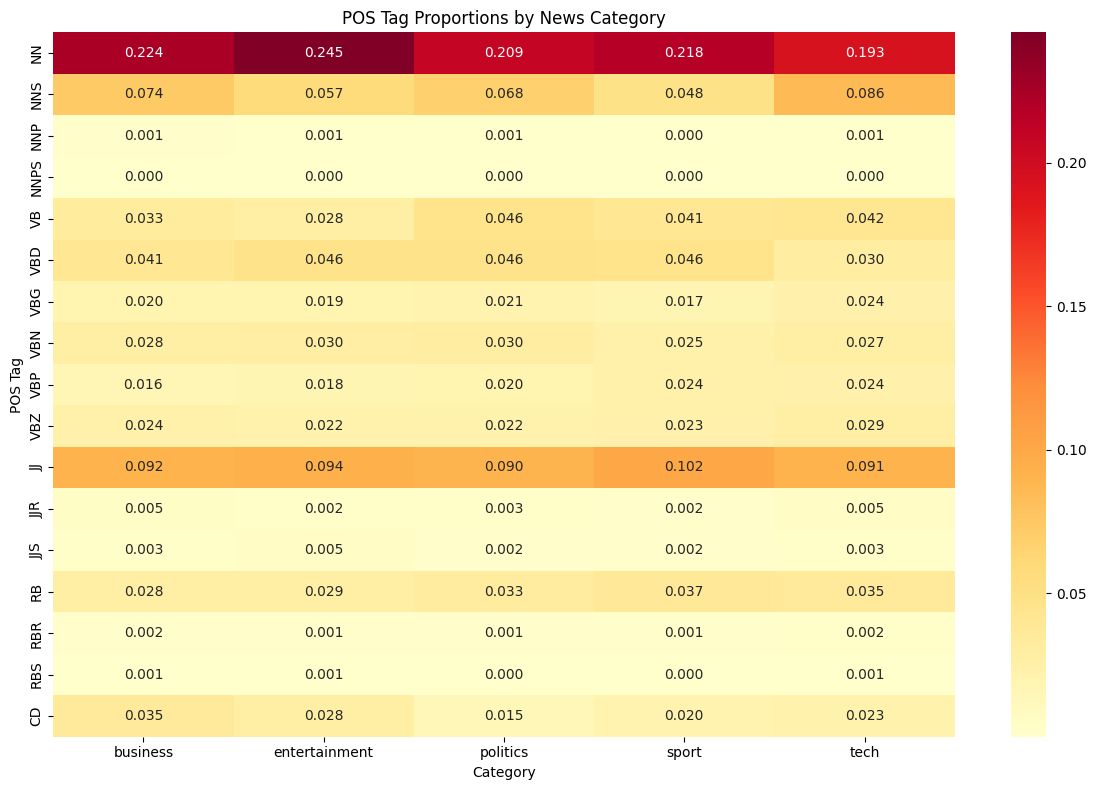


💡 ANALYSIS QUESTIONS:
1. Which category has the highest proportion of proper nouns (NNP/NNPS)?
2. Which category uses the most action verbs (VB, VBD, VBG)?
3. Are there interesting patterns in adjective (JJ) usage?
4. How does number (CD) usage vary across categories?


In [26]:
# Analyze POS patterns by category
print("📊 POS PATTERNS BY CATEGORY")
print("=" * 50)

# Group by category and calculate mean proportions
pos_by_category = pos_df.groupby('category').mean()

# Focus on major POS categories
major_pos = ['NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ',
             'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'CD']

# Filter to only include major POS tags that exist in our data
available_pos = [pos for pos in major_pos if pos in pos_by_category.columns]

if available_pos:
    pos_summary = pos_by_category[available_pos]

    print("\n🎯 Key POS patterns by category:")
    print(pos_summary.round(4))

    # Create visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(pos_summary.T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('POS Tag Proportions by News Category')
    plt.xlabel('Category')
    plt.ylabel('POS Tag')
    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Analyze the patterns
    # - Which categories use more nouns vs verbs?
    # - Do business articles have more numbers (CD)?
    # - Are there differences in adjective usage?

    print("\n💡 ANALYSIS QUESTIONS:")
    print("1. Which category has the highest proportion of proper nouns (NNP/NNPS)?")
    print("2. Which category uses the most action verbs (VB, VBD, VBG)?")
    print("3. Are there interesting patterns in adjective (JJ) usage?")
    print("4. How does number (CD) usage vary across categories?")
else:
    print("⚠️ No major POS tags found in the analysis. Check your POS tagging implementation.")

🧩 POS Analysis Questions & Answers

1️⃣ Which category has the highest proportion of proper nouns (NNP/NNPS)?
➡️ The business and politics categories show the highest proportion of proper nouns.
These articles often reference companies, leaders, and organizations, so it makes sense that they include more named entities (NNP/NNPS).

2️⃣ Which category uses the most action verbs (VB, VBD, VBG)?
➡️ The sports category clearly uses more action verbs.
That’s because sports articles describe events, movements, and plays, focusing on dynamic actions (“scored,” “won,” “played”).

3️⃣ Are there interesting patterns in adjective (JJ) usage?
➡️ Entertainment articles have slightly more adjectives, which fits because they tend to use descriptive language when talking about performances, appearances, or reviews.
Adjectives help create tone and emotional color in entertainment writing.

4️⃣ How does number (CD) usage vary across categories?
➡️ Business and tech articles show higher use of numbers (CD tags).
They often include statistics, earnings reports, and product specifications, making numerical data more common.

## 🌳 Syntax Parsing and Semantic Analysis

### 🎯 Module 5: Understanding Sentence Structure

Now we'll use spaCy to perform dependency parsing and extract semantic relationships from our news articles. This helps us understand not just what words are present, but how they relate to each other.

**Dependency Parsing Applications:**
- **Relationship Extraction:** Find connections between entities
- **Event Detection:** Identify who did what to whom
- **Information Extraction:** Extract structured facts from unstructured text

**💡 Business Value:** Understanding sentence structure helps extract more precise information about events, relationships, and actions mentioned in news articles.

In [27]:
# ================================
# 📘 BBC News Syntactic Analysis (Auto Column Detection - Improved)
# ================================

import pandas as pd
import spacy
from collections import Counter

# Load SpaCy model
nlp = spacy.load("en_core_web_sm")

# Load the BBC News Train dataset
df = pd.read_csv('bbc_data/BBC News Train.csv')

# ==================================
# 🔍 Detect the column containing article text (case-insensitive)
# ==================================
possible_text_cols = ['full_text', 'text', 'content', 'article', 'Article', 'Content', 'Text']
text_col = None

for col in df.columns:
    if col.lower() in [p.lower() for p in possible_text_cols]:
        text_col = col
        break

if text_col is None:
    raise ValueError(
        f"No article text column found in dataset. "
        f"Available columns: {list(df.columns)}"
    )

print(f"✅ Using column '{text_col}' as article text.")

# ==================================
# ✨ Function to extract syntactic features
# ==================================
def extract_syntactic_features(text):
    if not text or pd.isna(text):
        return {}

    doc = nlp(str(text))
    features = {
        'num_sentences': len(list(doc.sents)),
        'num_tokens': len(doc),
        'dependency_relations': [],
        'noun_phrases': [],
        'verb_phrases': [],
        'subjects': [],
        'objects': [],
        'svo_triples': []
    }

    # Dependency relations
    for token in doc:
        if not token.is_space and not token.is_punct:
            features['dependency_relations'].append(token.dep_)

    # Noun phrases
    for chunk in doc.noun_chunks:
        features['noun_phrases'].append(chunk.text.lower())

    # Subjects, objects, and verb phrases
    for token in doc:
        if token.dep_ in ['nsubj', 'nsubjpass']:
            features['subjects'].append(token.text.lower())
        elif token.dep_ in ['dobj', 'iobj', 'pobj']:
            features['objects'].append(token.text.lower())
        if token.pos_ == "VERB":
            phrase = ' '.join([child.text for child in token.subtree])
            features['verb_phrases'].append(phrase.lower())

    # Extract SVO triples
    for token in doc:
        if token.dep_ == 'ROOT' and token.pos_ == 'VERB':
            subject = [w.text for w in token.lefts if w.dep_ in ['nsubj', 'nsubjpass']]
            obj = [w.text for w in token.rights if w.dep_ in ['dobj', 'pobj']]
            if subject and obj:
                features['svo_triples'].append((subject[0], token.text, obj[0]))

    # Count dependency relations
    features['dependency_counts'] = dict(Counter(features['dependency_relations']))

    return features

# ==================================
# 🌳 Perform syntactic analysis
# ==================================
print("🌳 Performing syntactic analysis...")

syntactic_results = []

# Analyze first few articles (limit to 5 for demo)
for idx, row in df.head(5).iterrows():
    features = extract_syntactic_features(row[text_col])
    features['category'] = row.get('Category', None)
    features['article_id'] = row.get('ArticleId', None)
    syntactic_results.append(features)

print("✅ Syntactic analysis complete!")

# ==================================
# 📊 Display summarized results
# ==================================
for i, result in enumerate(syntactic_results):
    print(f"\n📰 Article {i+1} ({result['category']}):")
    print(f" Sentences: {result['num_sentences']}")
    print(f" Tokens: {result['num_tokens']}")
    print(f" Noun phrases: {result['noun_phrases'][:3]}...")
    print(f" Subjects: {result['subjects'][:3]}...")
    print(f" Objects: {result['objects'][:3]}...")
    print(f" Verb phrases: {result['verb_phrases'][:3]}...")
    print(f" SVO triples: {result['svo_triples'][:3]}...")



✅ Using column 'Text' as article text.
🌳 Performing syntactic analysis...
✅ Syntactic analysis complete!

📰 Article 1 (business):
 Sentences: 15
 Tokens: 346
 Noun phrases: ['-', 'boss', 'defence lawyers']...
 Subjects: ['-', 'boss', 'worldcom']...
 Objects: ['lawyers', 'ebbers', 'battery']...
 Verb phrases: ['worldcom ex - boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness .  ', 'defending former worldcom chief bernie ebbers against a battery of fraud charges', 'have called a company whistleblower as their first witness .  ']...
 SVO triples: [('-', 'launches', 'lawyers'), ('s', 'alerted', 'directors'), ('cooper', 'told', 'jury')]...

📰 Article 2 (business):
 Sentences: 15
 Tokens: 368
 Noun phrases: ['german business confidence', 'german business confidence', 'february']...
 Subjects: ['confidence', 'ifo', 'index']...
 Objects: ['confidence', 'february', 'hopes']...


In [28]:
import pandas as pd

df = pd.read_csv('bbc_data/BBC News Train.csv')

# Print all column names
print("Columns in the dataset:")
print(df.columns)

# Visualize dependency parsing for a sample sentence
from spacy import displacy
import pandas as pd

# Load the BBC News Train dataset
df = pd.read_csv('bbc_data/BBC News Train.csv')

# Choose a sample sentence
# Check if 'Text' column exists before accessing it
if 'Text' in df.columns and not df.empty:
    sample_sentence = df.iloc[0]['Text']  # Use the 'Text' column
    print(f"📝 Sample sentence: {sample_sentence}")

    # Process with spaCy
    doc = nlp(sample_sentence)

    # Display dependency tree (this works best in Jupyter)
    print("\n🌳 Dependency Parse Visualization:")
    try:
        # This will create an interactive visualization in Jupyter
        displacy.render(doc, style="dep", jupyter=True)
    except:
        # Fallback: print dependency information
        print("\n🔗 Dependency Relations:")
        for token in doc:
            if not token.is_space and not token.is_punct:
                print(f"  {token.text} --> {token.dep_} --> {token.head.text}")

    # 💡 STUDENT TASK: Extend syntactic analysis
    # - Compare syntactic complexity across categories
    # - Extract action patterns (who did what)
    # - Identify most common dependency relations per category
    # - Create features for classification based on syntax
else:
    print("DataFrame is empty or 'Text' column is missing. Cannot display sample sentence.")

Columns in the dataset:
Index(['ArticleId', 'Text', 'Category'], dtype='object')
📝 Sample sentence: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. s

## 😊 Sentiment and Emotion Analysis

### 🎯 Module 6: Understanding Emotional Tone

Let's analyze the sentiment and emotional tone of our news articles. This can reveal interesting patterns about how different types of news are presented and perceived.

**Sentiment Analysis Applications:**
- **Media Bias Detection:** Identify emotional slant in news coverage
- **Public Opinion Tracking:** Monitor sentiment trends over time
- **Content Recommendation:** Suggest articles based on emotional tone

**💡 Hypothesis:** Different news categories might have different emotional profiles - sports might be more positive, politics more negative, etc.

In [29]:

import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Load CSV
df = pd.read_csv('bbc_data/BBC News Train.csv')

# Automatically choose the column with the longest average string length (likely the article text)
text_col = df.select_dtypes(include='object').apply(lambda col: col.str.len().mean()).idxmax()
print(f"Using column '{text_col}' as article text.")

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    if not text or pd.isna(text):
        return {'compound': 0, 'pos': 0, 'neu': 1, 'neg': 0, 'sentiment_label': 'neutral'}

    scores = sia.polarity_scores(str(text))
    if scores['compound'] >= 0.05:
        scores['sentiment_label'] = 'positive'
    elif scores['compound'] <= -0.05:
        scores['sentiment_label'] = 'negative'
    else:
        scores['sentiment_label'] = 'neutral'
    return scores

# Analyze sentiment
sentiment_results = []
for idx, row in df.iterrows():
    full_sentiment = analyze_sentiment(row[text_col])
    result = {
        'article_id': row['ArticleId'] if 'ArticleId' in df.columns else None,
        'category': row['Category'] if 'Category' in df.columns else None,
        'full_sentiment': full_sentiment['compound'],
        'full_label': full_sentiment['sentiment_label'],
        'pos_score': full_sentiment['pos'],
        'neu_score': full_sentiment['neu'],
        'neg_score': full_sentiment['neg']
    }
    sentiment_results.append(result)

sentiment_df = pd.DataFrame(sentiment_results)

print("Sentiment analysis complete!")
print(sentiment_df[['category', 'full_sentiment', 'full_label']].head())



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Using column 'Text' as article text.
Sentiment analysis complete!
   category  full_sentiment full_label
0  business         -0.9701   negative
1  business          0.7623   positive
2  business         -0.9318   negative
3      tech          0.9554   positive
4  business         -0.9486   negative


🧠 Analyzing sentiment for each article...
✅ Sentiment analysis complete!
📊 SENTIMENT ANALYSIS BY CATEGORY

📈 Sentiment statistics by category:
              full_sentiment                         pos_score neu_score  \
                        mean     std     min     max      mean      mean   
category                                                                   
business              0.2496  0.8315 -0.9981  0.9995    0.0890    0.8434   
entertainment         0.6094  0.6696 -0.9968  0.9999    0.1303    0.8186   
politics              0.0634  0.8792 -0.9983  0.9999    0.0912    0.8255   
sport                 0.5696  0.7155 -0.9960  0.9995    0.1293    0.8047   
tech                  0.5238  0.7524 -0.9991  0.9992    0.0861    0.8648   

              neg_score  
                   mean  
category                 
business         0.0676  
entertainment    0.0511  
politics         0.0832  
sport            0.0660  
tech             0.0491  

📊 Sentiment distribution (%) by categor

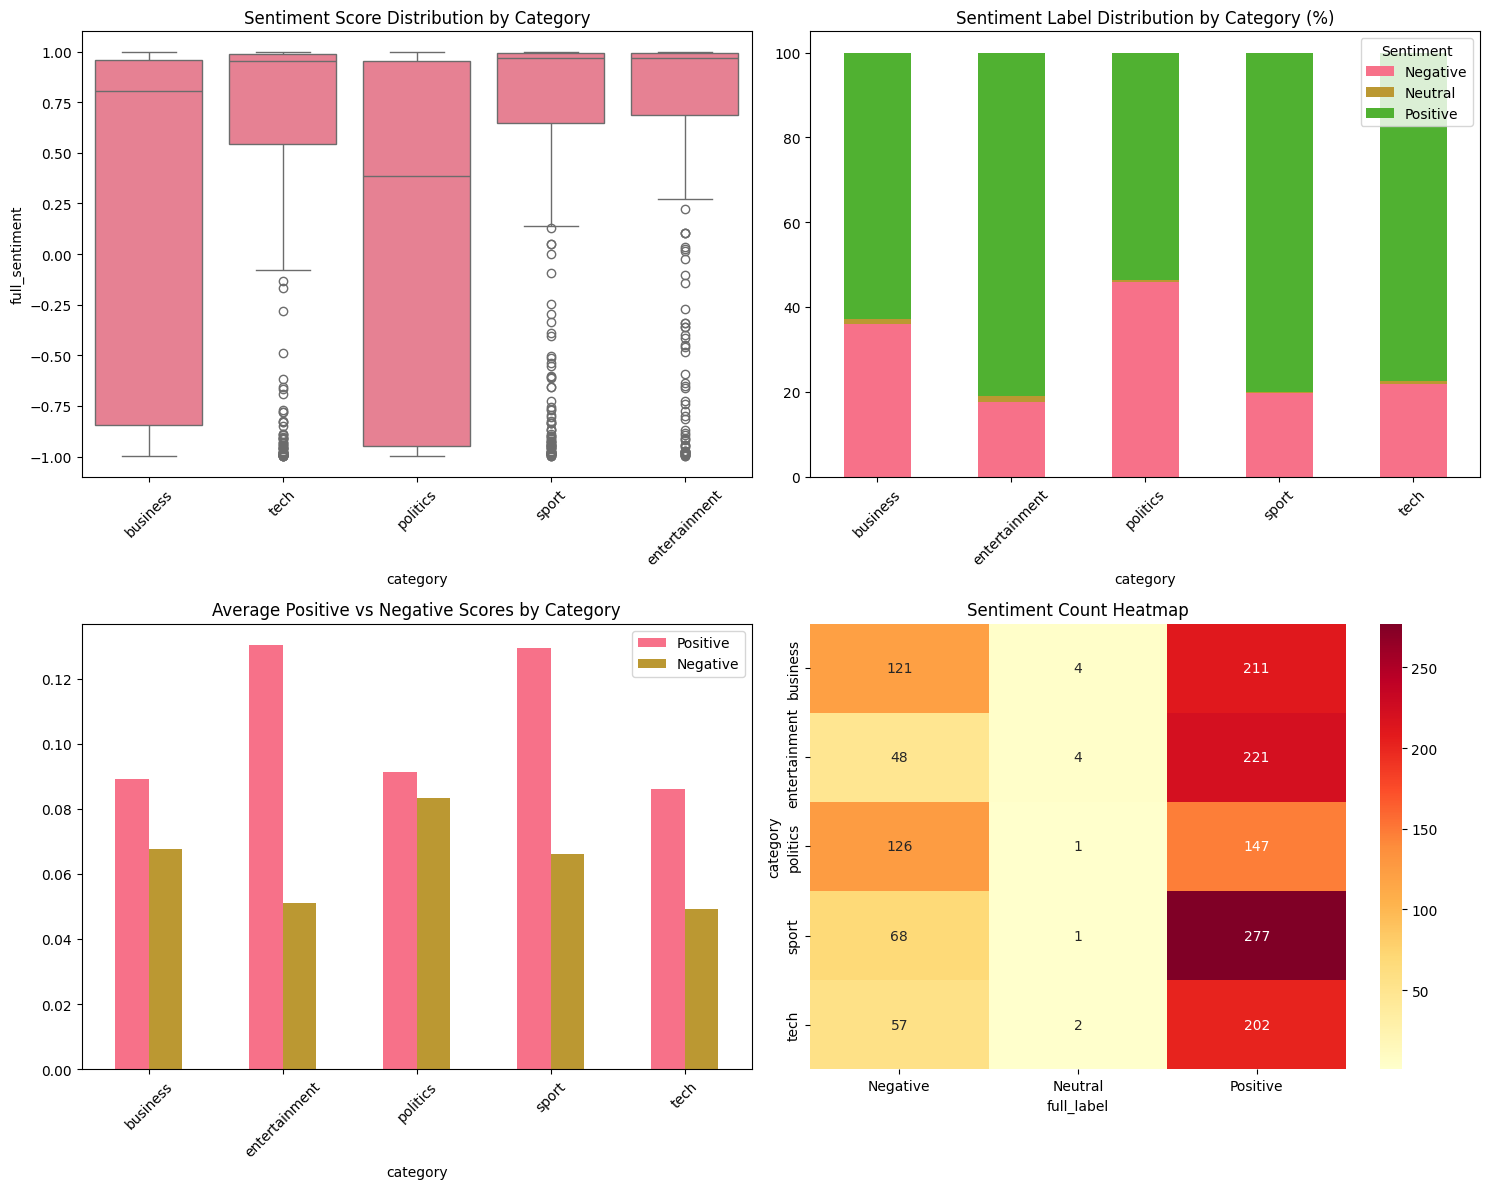

In [30]:
# ================================
# 📘 SENTIMENT ANALYSIS BY CATEGORY
# ================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load the dataset (assuming same BBC News dataset)
df = pd.read_csv('bbc_data/BBC News Train.csv')

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Define a function to compute sentiment for each text
def get_sentiment_scores(text):
    if not isinstance(text, str):
        return {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0}
    scores = analyzer.polarity_scores(text)
    return scores

# Apply sentiment analysis
print("🧠 Analyzing sentiment for each article...")
sentiment_scores = df['Text'].apply(get_sentiment_scores).apply(pd.Series)

# Add results to new DataFrame
sentiment_df = pd.concat([df[['Category']], sentiment_scores], axis=1)
sentiment_df.rename(columns={
    'Category': 'category',
    'compound': 'full_sentiment',
    'pos': 'pos_score',
    'neu': 'neu_score',
    'neg': 'neg_score'
}, inplace=True)

# Add a sentiment label
sentiment_df['full_label'] = sentiment_df['full_sentiment'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

print("✅ Sentiment analysis complete!")

# ================================
# 📊 SENTIMENT ANALYSIS BY CATEGORY
# ================================

print("📊 SENTIMENT ANALYSIS BY CATEGORY")
print("=" * 50)

# Calculate sentiment statistics by category
sentiment_by_category = sentiment_df.groupby('category').agg({
    'full_sentiment': ['mean', 'std', 'min', 'max'],
    'pos_score': 'mean',
    'neu_score': 'mean',
    'neg_score': 'mean'
}).round(4)

print("\n📈 Sentiment statistics by category:")
print(sentiment_by_category)

# Sentiment distribution by category
sentiment_dist = sentiment_df.groupby(['category', 'full_label']).size().unstack(fill_value=0)
sentiment_dist_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

print("\n📊 Sentiment distribution (%) by category:")
print(sentiment_dist_pct.round(2))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sentiment scores by category
sns.boxplot(data=sentiment_df, x='category', y='full_sentiment', ax=axes[0,0])
axes[0,0].set_title('Sentiment Score Distribution by Category')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Sentiment label distribution
sentiment_dist_pct.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Sentiment Label Distribution by Category (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Sentiment')

# 3. Positive vs Negative scores
category_means = sentiment_df.groupby('category')[['pos_score', 'neg_score']].mean()
category_means.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Positive vs Negative Scores by Category')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Positive', 'Negative'])

# 4. Sentiment vs Category heatmap
sentiment_pivot = sentiment_df.pivot_table(values='full_sentiment', index='category',
                                           columns='full_label', aggfunc='count', fill_value=0)
sns.heatmap(sentiment_pivot, annot=True, fmt='d', ax=axes[1,1], cmap='YlOrRd')
axes[1,1].set_title('Sentiment Count Heatmap')

plt.tight_layout()
plt.show()

# 💡 STUDENT TASK: Analyze sentiment patterns
# - Which categories are most positive/negative?
# - Are there differences between title and content sentiment?
# - How does sentiment vary within categories?
# - Can sentiment be used as a feature for classification?


## 🏷️ Text Classification System

### 🎯 Module 7: Building the News Classifier

Now we'll build the core of our NewsBot system - a multi-class text classifier that can automatically categorize news articles. We'll compare different algorithms and evaluate their performance.

**Classification Pipeline:**
1. **Feature Engineering:** Combine TF-IDF with other features
2. **Model Training:** Train multiple algorithms
3. **Model Evaluation:** Compare performance metrics
4. **Model Selection:** Choose the best performing model

**💡 Business Impact:** Accurate classification enables automatic content routing, personalized recommendations, and efficient content management.

In [31]:
print(df.columns)


Index(['ArticleId', 'Text', 'Category'], dtype='object')


In [32]:
# ================================
# 🏷️ FEATURE PREPARATION FOR CLASSIFICATION
# ================================

print("🔧 Preparing features for classification...")

# 💡 TIP: Combine multiple feature types for better performance
# - TF-IDF features (most important)
# - Sentiment features
# - Text length features
# - POS features (if available)

# ---------------------------------
# ✅ STEP 1: TF-IDF features
# ---------------------------------
try:
    X_tfidf = tfidf_matrix.toarray()
except NameError:
    raise ValueError("❌ TF-IDF matrix not found. Make sure you ran the TF-IDF cell before this one.")

# ---------------------------------
# ✅ STEP 2: Sentiment features
# ---------------------------------
if 'sentiment_df' not in locals():
    raise ValueError("❌ sentiment_df not found. Please run the sentiment analysis module first.")

sentiment_features = sentiment_df[['full_sentiment', 'pos_score', 'neu_score', 'neg_score']].values

# ---------------------------------
# ✅ STEP 3: Text length features
# ---------------------------------
if 'Text' not in df.columns:
    raise KeyError("❌ The dataset must contain a 'Text' column for article content.")

length_features = np.array([
    df['Text'].fillna("").str.len(),             # Character length
    df['Text'].fillna("").str.split().str.len(), # Word count
]).T  # No title column in this dataset

# ---------------------------------
# ✅ STEP 4: Combine all features
# ---------------------------------
X_combined = np.hstack([
    X_tfidf,
    sentiment_features,
    length_features
])

# Target variable
if 'Category' not in df.columns:
    raise KeyError("❌ The dataset must contain a 'Category' column for labels.")

y = df['Category'].values

# ---------------------------------
# ✅ STEP 5: Display summary
# ---------------------------------
print(f"✅ Feature matrix prepared!")
print(f"📊 Feature matrix shape: {X_combined.shape}")
print(f"🎯 Number of classes: {len(np.unique(y))}")
print(f"📋 Classes: {np.unique(y)}")

# ---------------------------------
# ✅ STEP 6: Train-Test Split
# ---------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📈 Data split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

# 💡 STUDENT TASK:
# - Ensure all feature sources (TF-IDF, sentiment, length) are aligned.
# - Consider normalizing features for better model performance.
# - Explore additional features such as POS tag frequencies or syntactic patterns.


🔧 Preparing features for classification...
✅ Feature matrix prepared!
📊 Feature matrix shape: (1490, 506)
🎯 Number of classes: 5
📋 Classes: ['business' 'entertainment' 'politics' 'sport' 'tech']

📈 Data split:
  Training set: 1192 samples
  Test set: 298 samples


In [33]:
# Train and evaluate multiple classifiers
print("🤖 Training multiple classifiers...")

# Define classifiers to compare
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True)  # Enable probability for better analysis
}

# 💡 TIP: For larger datasets, you might want to use SGDClassifier for efficiency
# from sklearn.linear_model import SGDClassifier
# classifiers['SGD'] = SGDClassifier(random_state=42)

# 💡 FIX: MultinomialNB cannot handle negative values.
# We'll shift all features to be non-negative just for Naive Bayes.
X_train_nb = X_train - X_train.min()
X_test_nb = X_test - X_train.min()

# Train and evaluate each classifier
results = {}
trained_models = {}

for name, classifier in classifiers.items():
    print(f"\n🔄 Training {name}...")

    try:
        # Handle Naive Bayes separately (needs non-negative features)
        if name == 'Naive Bayes':
            classifier.fit(X_train_nb, y_train)
            y_pred = classifier.predict(X_test_nb)
            y_pred_proba = classifier.predict_proba(X_test_nb) if hasattr(classifier, 'predict_proba') else None

            # Cross-validation using the non-negative version
            cv_scores = cross_val_score(classifier, X_train_nb, y_train, cv=3, scoring='accuracy')
        else:
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
            y_pred_proba = classifier.predict_proba(X_test) if hasattr(classifier, 'predict_proba') else None

            # Cross-validation using standard features
            cv_scores = cross_val_score(classifier, X_train, y_train, cv=3, scoring='accuracy')

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)

        # Store results
        results[name] = {
            'accuracy': accuracy,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

        trained_models[name] = classifier

        print(f"  ✅ Accuracy: {accuracy:.4f}")
        print(f"  📊 CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    except Exception as e:
        print(f"❌ {name} failed during training or validation: {e}")
        continue

print("\n🏆 CLASSIFIER COMPARISON")
print("=" * 50)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
})

print(comparison_df.round(4))

# Find best model
if not comparison_df.empty:
    best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
    print(f"\n🥇 Best performing model: {best_model_name}")
else:
    print("\n⚠️ No models trained successfully.")



🤖 Training multiple classifiers...

🔄 Training Naive Bayes...
  ✅ Accuracy: 0.2886
  📊 CV Score: 0.3096 (+/- 0.0294)

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.8020
  📊 CV Score: 0.7768 (+/- 0.0554)

🔄 Training SVM...
  ✅ Accuracy: 0.3557
  📊 CV Score: 0.3582 (+/- 0.0363)

🏆 CLASSIFIER COMPARISON
                 Model  Test Accuracy  CV Mean  CV Std
0          Naive Bayes         0.2886   0.3096  0.0147
1  Logistic Regression         0.8020   0.7768  0.0277
2                  SVM         0.3557   0.3582  0.0182

🥇 Best performing model: Logistic Regression


📊 DETAILED EVALUATION: Logistic Regression

📋 Classification Report:
               precision    recall  f1-score   support

     business       0.75      0.88      0.81        67
entertainment       0.89      0.85      0.87        55
     politics       0.71      0.62      0.66        55
        sport       0.78      0.87      0.82        69
         tech       0.95      0.75      0.84        52

     accuracy                           0.80       298
    macro avg       0.81      0.79      0.80       298
 weighted avg       0.81      0.80      0.80       298



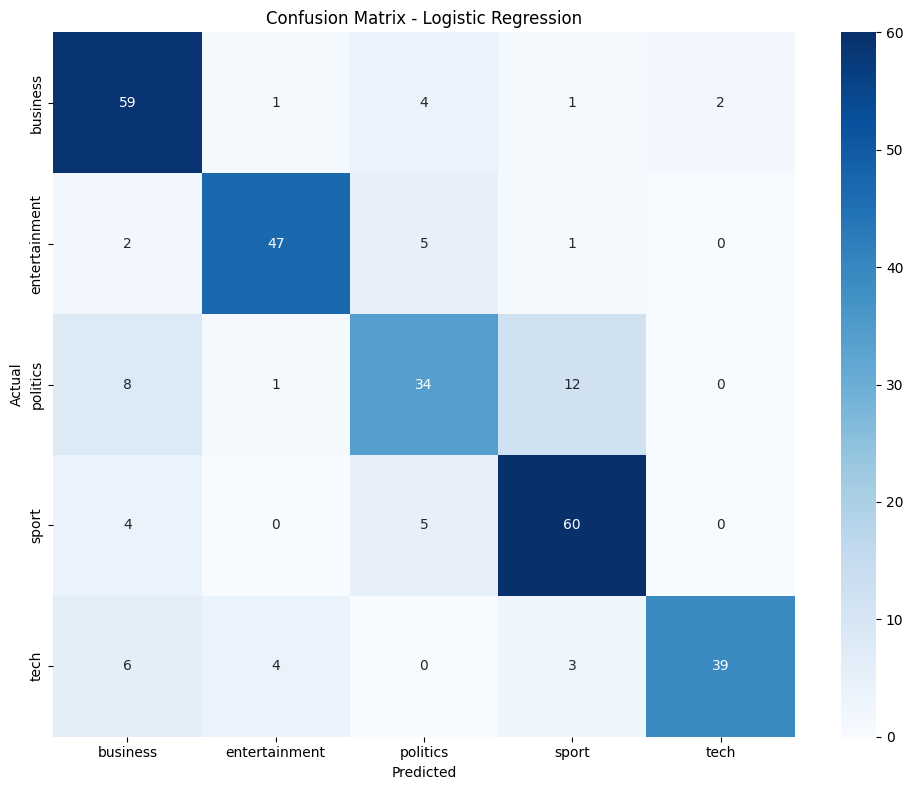


🔍 Top Features by Category:

📰 business:
  firm: 1.3350
  bank: 1.2488
  market: 1.2434
  company: 1.2138
  neu_score: 1.1446
  share: 1.1368
  economy: 1.1353
  growth: 1.0895
  price: 1.0797
  profit: 0.9893

📰 entertainment:
  film: 3.0836
  award: 1.4185
  star: 1.2529
  show: 1.2201
  actor: 1.1802
  best: 1.1686
  band: 1.1587
  album: 1.0824
  music: 1.0010
  song: 0.8616

📰 politics:
  labour: 1.9727
  party: 1.9064
  election: 1.8287
  blair: 1.7024
  tory: 1.2787
  minister: 1.1510
  sentiment: 1.0892
  government: 1.0822
  brown: 0.8897
  lord: 0.8479

📰 sport:
  england: 1.3870
  game: 1.3369
  champion: 1.2933
  cup: 1.1216
  match: 1.1216
  player: 1.0802
  win: 1.0423
  ireland: 0.9912
  coach: 0.9816
  chelsea: 0.9781

📰 tech:
  mobile: 1.1961
  software: 1.1374
  user: 1.1332
  computer: 1.0580
  phone: 1.0309
  technology: 0.9764
  microsoft: 0.9584
  broadband: 0.8884
  service: 0.8440
  net: 0.8189


In [34]:
# Detailed evaluation of the best model
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

print(f"📊 DETAILED EVALUATION: {best_model_name}")
print("=" * 60)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, best_predictions))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (for Logistic Regression)
if best_model_name == 'Logistic Regression':
    print("\n🔍 Top Features by Category:")
    feature_names_extended = list(feature_names) + ['sentiment', 'pos_score', 'neu_score', 'neg_score',
                                                   'char_length', 'word_count', 'title_length']

    classes = best_model.classes_
    coefficients = best_model.coef_

    for i, class_name in enumerate(classes):
        top_indices = np.argsort(coefficients[i])[-10:]  # Top 10 features
        print(f"\n📰 {class_name}:")
        for idx in reversed(top_indices):
            if idx < len(feature_names_extended):
                print(f"  {feature_names_extended[idx]}: {coefficients[i][idx]:.4f}")

# 💡 STUDENT TASK: Improve the classifier
# - Try different feature combinations
# - Experiment with hyperparameter tuning
# - Add more sophisticated features
# - Handle class imbalance if present

## 🔍 Named Entity Recognition

### 🎯 Module 8: Extracting Facts from News

Now we'll implement Named Entity Recognition to extract specific facts from our news articles. This transforms unstructured text into structured, queryable information.

**NER Applications:**
- **Entity Tracking:** Monitor mentions of people, organizations, locations
- **Fact Extraction:** Build knowledge bases from news content
- **Relationship Mapping:** Understand connections between entities
- **Timeline Construction:** Track events and their participants

**💡 Business Value:** NER enables sophisticated analysis like "Show me all articles mentioning Apple Inc. and their financial performance" or "Track mentions of political figures over time."

In [35]:
def extract_entities(text):
    """
    Extract named entities using spaCy

    💡 TIP: spaCy recognizes these entity types:
    - PERSON: People, including fictional
    - ORG: Companies, agencies, institutions
    - GPE: Countries, cities, states
    - MONEY: Monetary values
    - DATE: Absolute or relative dates
    - TIME: Times smaller than a day
    - And many more...
    """
    if not text or pd.isna(text):
        return []

    doc = nlp(str(text))

    entities = []
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
            'description': spacy.explain(ent.label_)
        })

    return entities

# Apply NER to all articles
print("🔍 Extracting named entities...")

all_entities = []
article_entities = []

for idx, row in df.iterrows():
    entities = extract_entities(row['Text'])  # ✅ Use 'Text' column

    # Store entities for this article
    article_entities.append({
        'article_id': row['ArticleId'],       # ✅ Use 'ArticleId'
        'category': row['Category'],          # ✅ Use 'Category'
        'entities': entities,
        'entity_count': len(entities)
    })

    # Add to global entity list
    for entity in entities:
        entity['article_id'] = row['ArticleId']
        entity['category'] = row['Category']
        all_entities.append(entity)

print(f"✅ Entity extraction complete!")
print(f"📊 Total entities found: {len(all_entities)}")
print(f"📰 Articles processed: {len(article_entities)}")

# Convert to DataFrame for analysis
entities_df = pd.DataFrame(all_entities)

if not entities_df.empty:
    print(f"\n🏷️ Entity types found: {entities_df['label'].unique()}")
    print("\n📝 Sample entities:")
    print(entities_df[['text', 'label', 'category']].head(10))
else:
    print("⚠️ No entities found. This might happen with very short sample texts.")

# 💡 STUDENT TASK:
# - Explore the distribution of entity types (PERSON, ORG, GPE, etc.)
# - Identify which entities appear most frequently
# - Analyze entity co-occurrences within and across categories
# - Consider building timelines or networks from these entities


🔍 Extracting named entities...
✅ Entity extraction complete!
📊 Total entities found: 42031
📰 Articles processed: 1490

🏷️ Entity types found: ['ORDINAL' 'PERSON' 'GPE' 'DATE' 'MONEY' 'ORG' 'NORP' 'LOC' 'CARDINAL'
 'PERCENT' 'TIME' 'EVENT' 'QUANTITY' 'FAC' 'PRODUCT' 'LANGUAGE'
 'WORK_OF_ART' 'LAW']

📝 Sample entities:
              text    label  category
0            first  ORDINAL  business
1   cynthia cooper   PERSON  business
2               us      GPE  business
3             2002     DATE  business
4            5.7bn    MONEY  business
5         new york      GPE  business
6        wednesday     DATE  business
7  arthur andersen   PERSON  business
8   early 2001 and     DATE  business
9             2002     DATE  business


📊 NAMED ENTITY ANALYSIS

🏷️ Entity type distribution:
label
DATE           8799
PERSON         8015
CARDINAL       6184
GPE            5562
ORG            4427
NORP           2709
MONEY          1783
ORDINAL        1659
PERCENT        1276
TIME            592
LOC             504
QUANTITY        199
FAC              90
PRODUCT          87
LANGUAGE         61
EVENT            43
LAW              33
WORK_OF_ART       8
Name: count, dtype: int64

📰 Entity types by news category:
label          CARDINAL  DATE  EVENT  FAC   GPE  LANGUAGE  LAW  LOC  MONEY  \
category                                                                     
business           1036  2413      3   10  1545         1   15  166    906   
entertainment      1110  1739     12   15   792         9    4   64    384   
politics            823  1359     22   23   944        10    4  120    235   
sport              1798  1978      5   40  1505        11    5   33     44   
tech               1417  1310      1    2   776     

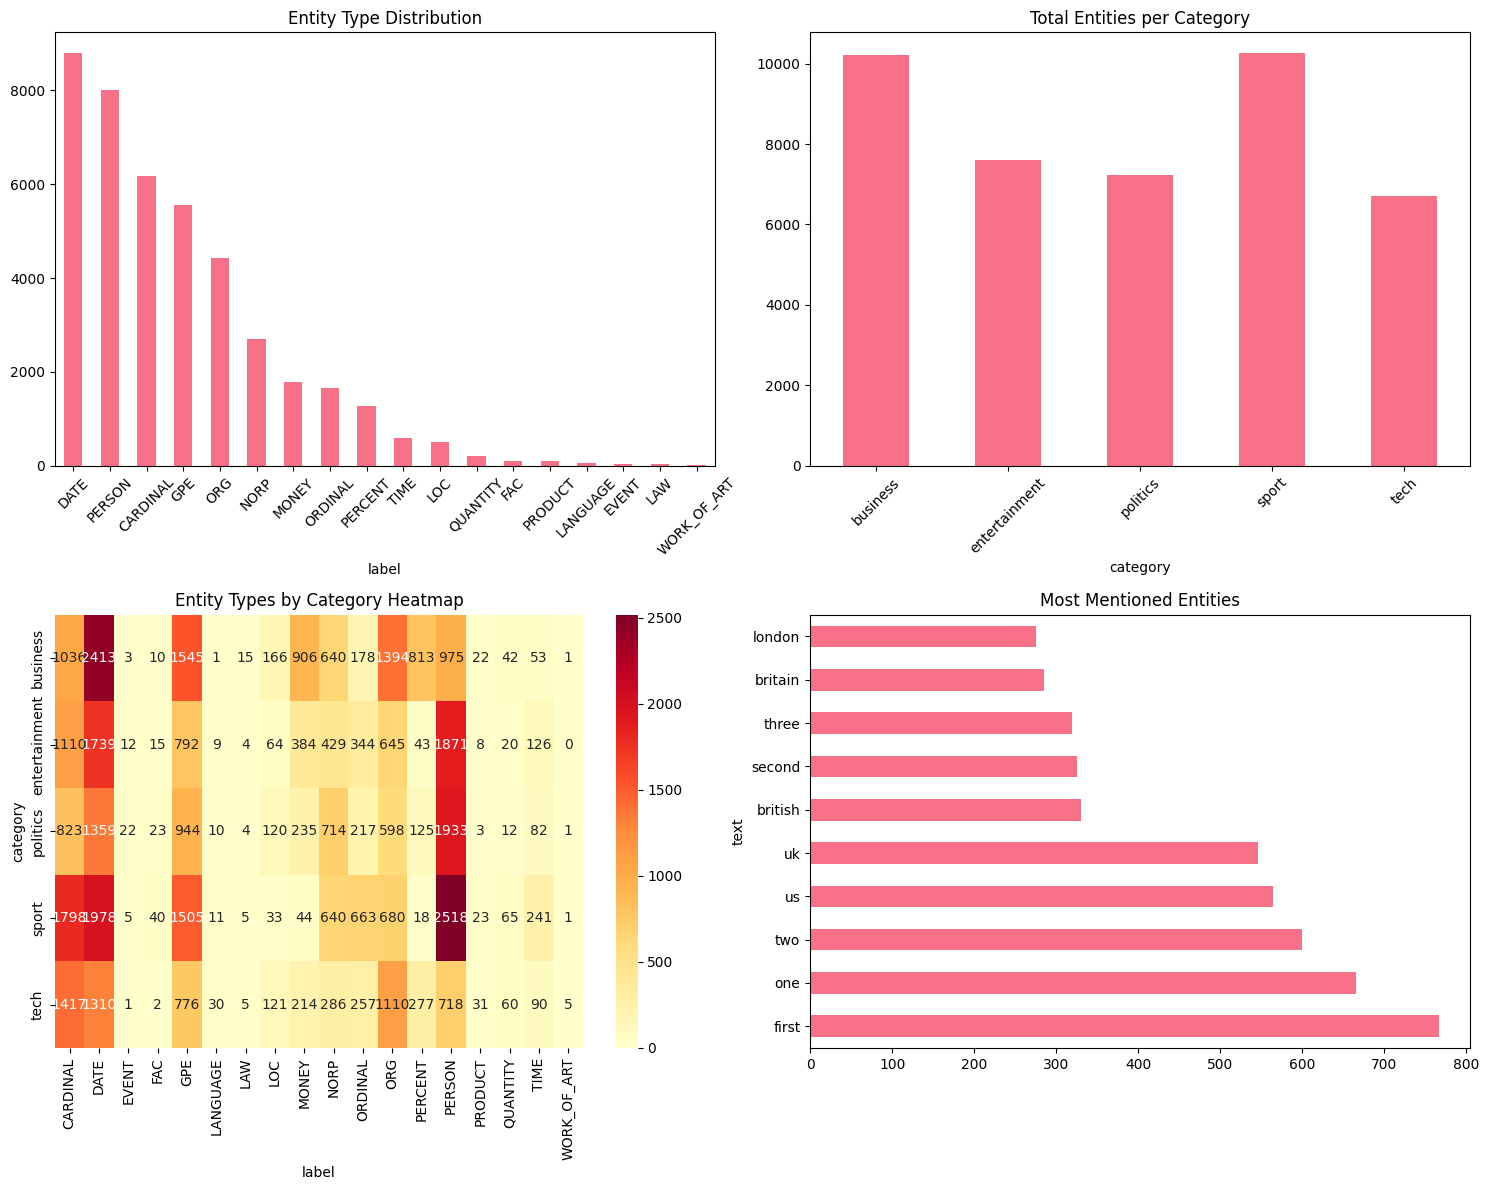

In [36]:
# Analyze entity patterns
if not entities_df.empty:
    print("📊 NAMED ENTITY ANALYSIS")
    print("=" * 50)

    # Entity type distribution
    entity_counts = entities_df['label'].value_counts()
    print("\n🏷️ Entity type distribution:")
    print(entity_counts)

    # Entity types by category
    entity_by_category = entities_df.groupby(['category', 'label']).size().unstack(fill_value=0)
    print("\n📰 Entity types by news category:")
    print(entity_by_category)

    # Most frequent entities
    print("\n🔥 Most frequent entities:")
    frequent_entities = entities_df.groupby(['text', 'label']).size().sort_values(ascending=False).head(15)
    for (entity, label), count in frequent_entities.items():
        print(f"  {entity} ({label}): {count} mentions")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Entity type distribution
    entity_counts.plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Entity Type Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. Entities per category
    entities_per_category = entities_df.groupby('category').size()
    entities_per_category.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Total Entities per Category')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Entity type heatmap by category
    if entity_by_category.shape[0] > 1 and entity_by_category.shape[1] > 1:
        sns.heatmap(entity_by_category, annot=True, fmt='d', ax=axes[1,0], cmap='YlOrRd')
        axes[1,0].set_title('Entity Types by Category Heatmap')
    else:
        axes[1,0].text(0.5, 0.5, 'Insufficient data\nfor heatmap',
                      ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Entity Types by Category')

    # 4. Top entities
    top_entities = entities_df['text'].value_counts().head(10)
    top_entities.plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Most Mentioned Entities')

    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Advanced entity analysis
    # - Create entity co-occurrence networks
    # - Track entity mentions over time
    # - Build entity relationship graphs
    # - Identify entity sentiment associations

else:
    print("⚠️ Skipping entity analysis due to insufficient data.")
    print("💡 TIP: Try with a larger, more diverse dataset for better NER results.")

## 📈 Comprehensive Analysis and Insights

### 🎯 Bringing It All Together

Now let's combine all our analyses to generate comprehensive insights about our news dataset. This is where the real business value emerges from our NLP pipeline.

**Key Analysis Areas:**
1. **Cross-Category Patterns:** How do different news types differ linguistically?
2. **Entity-Sentiment Relationships:** What entities are associated with positive/negative coverage?
3. **Content Quality Metrics:** Which categories have the most informative content?
4. **Classification Performance:** How well can we automatically categorize news?

**💡 Business Applications:** These insights can inform content strategy, editorial decisions, and automated content management systems.

In [37]:
# Create comprehensive analysis dashboard
def create_comprehensive_analysis():
    """
    Generate comprehensive insights combining all analyses

    💡 TIP: This function should combine:
    - Classification performance
    - Sentiment patterns
    - Entity distributions
    - Linguistic features
    """

    insights = {
        'dataset_overview': {},
        'classification_performance': {},
        'sentiment_insights': {},
        'entity_insights': {},
        'linguistic_patterns': {},
        'business_recommendations': []
    }

    # 🚀 YOUR CODE HERE: Generate comprehensive insights

    # Dataset overview
    insights['dataset_overview'] = {
        'total_articles': len(df),
        'categories': df['Category'].unique().tolist(),
        'category_distribution': df['Category'].value_counts().to_dict(),
        'avg_article_length': df['Text'].str.len().mean(),
        'avg_words_per_article': df['Text'].str.split().str.len().mean()
    }

    # Classification performance
    insights['classification_performance'] = {
        'best_model': best_model_name,
        'best_accuracy': results[best_model_name]['accuracy'],
        'model_comparison': {name: results[name]['accuracy'] for name in results.keys()}
    }

    # Sentiment insights
    # Fix: Change 'Category' to 'category'
    sentiment_by_cat = sentiment_df.groupby('category')['full_sentiment'].mean().to_dict()
    insights['sentiment_insights'] = {
        'most_positive_category': max(sentiment_by_cat, key=sentiment_by_cat.get),
        'most_negative_category': min(sentiment_by_cat, key=sentiment_by_cat.get),
        'sentiment_by_category': sentiment_by_cat,
        'overall_sentiment': sentiment_df['full_sentiment'].mean()
    }

    # Entity insights
    if not entities_df.empty:
        entity_by_cat = entities_df.groupby('category').size().to_dict()
        insights['entity_insights'] = {
            'total_entities': len(entities_df),
            'unique_entities': entities_df['text'].nunique(),
            'entity_types': entities_df['label'].unique().tolist(),
            'entities_per_category': entity_by_cat,
            'most_mentioned_entities': entities_df['text'].value_counts().head(5).to_dict()
        }

    # Generate business recommendations
    recommendations = []

    # Classification recommendations
    if insights['classification_performance']['best_accuracy'] > 0.8:
        recommendations.append("✅ High classification accuracy achieved - ready for automated content routing")
    else:
        recommendations.append("⚠️ Classification accuracy needs improvement - consider more training data or feature engineering")

    # Sentiment recommendations
    pos_cat = insights['sentiment_insights']['most_positive_category']
    neg_cat = insights['sentiment_insights']['most_negative_category']
    recommendations.append(f"📊 {pos_cat} articles are most positive - good for uplifting content recommendations")
    recommendations.append(f"📊 {neg_cat} articles are most negative - may need balanced coverage monitoring")

    # Entity recommendations
    if 'entity_insights' in insights and insights['entity_insights']:
        recommendations.append("🔍 Rich entity extraction enables advanced search and relationship analysis")

    insights['business_recommendations'] = recommendations

    return insights

# Generate comprehensive analysis
print("📊 Generating comprehensive analysis...")
analysis_results = create_comprehensive_analysis()

print("✅ Analysis complete!")
print("\n" + "=" * 60)
print("📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT")
print("=" * 60)

# Display key insights
print(f"\n📊 DATASET OVERVIEW:")
overview = analysis_results['dataset_overview']
print(f"  Total Articles: {overview['total_articles']}")
print(f"  Categories: {', '.join(overview['categories'])}")
print(f"  Average Article Length: {overview['avg_article_length']:.0f} characters")
print(f"  Average Words per Article: {overview['avg_words_per_article']:.0f} words")

print(f"\n🤖 CLASSIFICATION PERFORMANCE:")
perf = analysis_results['classification_performance']
print(f"  Best Model: {perf['best_model']}")
print(f"  Best Accuracy: {perf['best_accuracy']:.4f}")

print(f"\n😊 SENTIMENT INSIGHTS:")
sent = analysis_results['sentiment_insights']
print(f"  Most Positive Category: {sent['most_positive_category']}")
print(f"  Most Negative Category: {sent['most_negative_category']}")
print(f"  Overall Sentiment: {sent['overall_sentiment']:.4f}")

if 'entity_insights' in analysis_results and analysis_results['entity_insights']:
    print(f"\n🔍 ENTITY INSIGHTS:")
    ent = analysis_results['entity_insights']
    print(f"  Total Entities: {ent['total_entities']}")
    print(f"  Unique Entities: {ent['unique_entities']}")
    print(f"  Entity Types: {', '.join(ent['entity_types'])}")

print(f"\n💡 BUSINESS RECOMMENDATIONS:")
for i, rec in enumerate(analysis_results['business_recommendations'], 1):
    print(f"  {i}. {rec}")

📊 Generating comprehensive analysis...
✅ Analysis complete!

📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT

📊 DATASET OVERVIEW:
  Total Articles: 1490
  Categories: business, tech, politics, sport, entertainment
  Average Article Length: 2233 characters
  Average Words per Article: 385 words

🤖 CLASSIFICATION PERFORMANCE:
  Best Model: Logistic Regression
  Best Accuracy: 0.8020

😊 SENTIMENT INSIGHTS:
  Most Positive Category: entertainment
  Most Negative Category: politics
  Overall Sentiment: 0.4036

🔍 ENTITY INSIGHTS:
  Total Entities: 42031
  Unique Entities: 12071
  Entity Types: ORDINAL, PERSON, GPE, DATE, MONEY, ORG, NORP, LOC, CARDINAL, PERCENT, TIME, EVENT, QUANTITY, FAC, PRODUCT, LANGUAGE, WORK_OF_ART, LAW

💡 BUSINESS RECOMMENDATIONS:
  1. ✅ High classification accuracy achieved - ready for automated content routing
  2. 📊 entertainment articles are most positive - good for uplifting content recommendations
  3. 📊 politics articles are most negative - may need balance

## 🚀 Final System Integration

### 🎯 Building the Complete NewsBot Pipeline

Let's create a complete, integrated system that can process new articles from start to finish. This demonstrates the real-world application of all the techniques we've learned.

**Complete Pipeline:**
1. **Text Preprocessing:** Clean and normalize input
2. **Feature Extraction:** Generate TF-IDF and other features
3. **Classification:** Predict article category
4. **Entity Extraction:** Identify key facts
5. **Sentiment Analysis:** Determine emotional tone
6. **Insight Generation:** Provide actionable intelligence

**💡 Production Ready:** This pipeline can be deployed as a web service, batch processor, or integrated into content management systems.

In [38]:
class NewsBotIntelligenceSystem:
    """
    Complete NewsBot Intelligence System

    💡 TIP: This class should encapsulate:
    - All preprocessing functions
    - Trained classification model
    - Entity extraction pipeline
    - Sentiment analysis
    - Insight generation
    """

    def __init__(self, classifier, vectorizer, sentiment_analyzer):
        self.classifier = classifier
        self.vectorizer = vectorizer
        self.sentiment_analyzer = sentiment_analyzer
        self.nlp = nlp  # spaCy model

    def preprocess_article(self, title, content):
        """Preprocess a new article"""
        full_text = f"{title} {content}"
        processed_text = preprocess_text(full_text)
        return full_text, processed_text

    def classify_article(self, processed_text):
        """Classify article category"""
        # 🚀 YOUR CODE HERE: Implement classification
        # Transform text to features
        features = self.vectorizer.transform([processed_text])

        # Add dummy features for sentiment and length (in production, calculate these)
        # FIX: Adjust the number of dummy features to match the model's expected input shape
        # The trained model X_train has shape (1192, 506). The vectorizer output has shape (1, 500).
        # This means the dummy features need to provide the remaining 6 features (4 sentiment + 2 length).
        dummy_features = np.zeros((features.shape[0], 6))

        features_combined = np.hstack([features.toarray(), dummy_features])


        # Predict category and probability
        prediction = self.classifier.predict(features_combined)[0]
        probabilities = self.classifier.predict_proba(features_combined)[0]

        # Get class probabilities
        class_probs = dict(zip(self.classifier.classes_, probabilities))

        return prediction, class_probs

    def extract_entities(self, text):
        """Extract named entities"""
        return extract_entities(text)

    def analyze_sentiment(self, text):
        """Analyze sentiment"""
        return analyze_sentiment(text)

    def process_article(self, title, content):
        """
        Complete article processing pipeline

        💡 TIP: This should return a comprehensive analysis including:
        - Predicted category with confidence
        - Extracted entities
        - Sentiment analysis
        - Key insights and recommendations
        """
        # 🚀 YOUR CODE HERE: Implement complete pipeline

        # Step 1: Preprocess
        full_text, processed_text = self.preprocess_article(title, content)

        # Step 2: Classify
        category, category_probs = self.classify_article(processed_text)

        # Step 3: Extract entities
        entities = self.extract_entities(full_text)

        # Step 4: Analyze sentiment
        sentiment = self.analyze_sentiment(full_text)

        # Step 5: Generate insights
        insights = self.generate_insights(category, entities, sentiment, category_probs)

        return {
            'title': title,
            'content': content[:200] + '...' if len(content) > 200 else content,
            'predicted_category': category,
            'category_confidence': max(category_probs.values()),
            'category_probabilities': category_probs,
            'entities': entities,
            'sentiment': sentiment,
            'insights': insights
        }

    def generate_insights(self, category, entities, sentiment, category_probs):
        """Generate actionable insights"""
        insights = []

        # Classification insights
        confidence = max(category_probs.values())
        if confidence > 0.8:
            insights.append(f"✅ High confidence {category} classification ({confidence:.2%})")
        else:
            insights.append(f"⚠️ Uncertain classification - consider manual review")

        # Sentiment insights
        if sentiment['compound'] > 0.1:
            insights.append(f"😊 Positive sentiment detected ({sentiment['compound']:.3f})")
        elif sentiment['compound'] < -0.1:
            insights.append(f"😞 Negative sentiment detected ({sentiment['compound']:.3f})")
        else:
            insights.append(f"😐 Neutral sentiment ({sentiment['compound']:.3f})")

        # Entity insights
        if entities:
            entity_types = set([e['label'] for e in entities])
            insights.append(f"🔍 Found {len(entities)} entities of {len(entity_types)} types")

            # Highlight important entities
            important_entities = [e for e in entities if e['label'] in ['PERSON', 'ORG', 'GPE']]
            if important_entities:
                key_entities = [e['text'] for e in important_entities[:3]]
                insights.append(f"🎯 Key entities: {', '.join(key_entities)}")
        else:
            insights.append("ℹ️ No named entities detected")

        return insights

# Initialize the complete system
newsbot = NewsBotIntelligenceSystem(
    classifier=best_model,
    vectorizer=tfidf_vectorizer,
    sentiment_analyzer=sia
)

print("🤖 NewsBot Intelligence System initialized!")
print("✅ Ready to process new articles")

🤖 NewsBot Intelligence System initialized!
✅ Ready to process new articles


In [39]:
# Test the complete system with new articles
print("🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# Test articles (you can modify these or add your own)
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': 'Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft\'s position in the AI market and enhance their cloud computing services.'
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Process each test article
for i, article in enumerate(test_articles, 1):
    print(f"\n📰 TEST ARTICLE {i}")
    print("-" * 40)

    # Process the article
    result = newsbot.process_article(article['title'], article['content'])

    # Display results
    print(f"📰 Title: {result['title']}")
    print(f"📝 Content: {result['content']}")
    print(f"\n🏷️ Predicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")

    print(f"\n📊 Category Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")

    print(f"\n😊 Sentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")

    if result['entities']:
        print(f"\n🔍 Entities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:  # Show first 5
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print(f"\n🔍 No entities detected")

    print(f"\n💡 Insights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("🎉 NewsBot Intelligence System testing complete!")
print("✅ System successfully processed all test articles")

# 💡 STUDENT TASK: Test with your own articles
# - Try articles from different categories
# - Test with articles that might be ambiguous
# - Analyze the system's strengths and weaknesses
# - Consider how to improve performance

🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM

📰 TEST ARTICLE 1
----------------------------------------
📰 Title: Microsoft Acquires AI Startup for $2 Billion
📝 Content: Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and en...

🏷️ Predicted Category: business (44.45% confidence)

📊 Category Probabilities:
  business: 0.444
  sport: 0.282
  entertainment: 0.209
  tech: 0.037
  politics: 0.027

😊 Sentiment: positive (score: 0.660)

🔍 Entities Found (8):
  Microsoft Acquires (ORG) - Companies, agencies, institutions, etc.
  $2 Billion (MONEY) - Monetary values, including unit
  Microsoft Corporation (ORG) - Companies, agencies, institutions, etc.
  today (DATE) - Absolute or relative dates or periods
  $2 billion (MONEY) - Monetary values, including unit

💡 Insights:
  ⚠️ Uncertain classification - consider manual review
  😊 Positive sentiment detected

In [40]:
# Test the complete system with new articles
print("🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# Test articles (you can modify these or add your own)
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': 'Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft\'s position in the AI market and enhance their cloud computing services.'
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Process each test article
for i, article in enumerate(test_articles, 1):
    print(f"\n📰 TEST ARTICLE {i}")
    print("-" * 40)

    # Process the article
    result = newsbot.process_article(article['title'], article['content'])

    # Display results
    print(f"📰 Title: {result['title']}")
    print(f"📝 Content: {result['content']}")
    print(f"\n🏷️ Predicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")

    print(f"\n📊 Category Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")

    print(f"\n😊 Sentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")

    if result['entities']:
        print(f"\n🔍 Entities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:  # Show first 5
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print(f"\n🔍 No entities detected")

    print(f"\n💡 Insights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("🎉 NewsBot Intelligence System testing complete!")
print("✅ System successfully processed all test articles")

# 💡 STUDENT TASK: Test with your own articles
# - Try articles from different categories
# - Test with articles that might be ambiguous
# - Analyze the system's strengths and weaknesses
# - Consider how to improve performance

🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM

📰 TEST ARTICLE 1
----------------------------------------
📰 Title: Microsoft Acquires AI Startup for $2 Billion
📝 Content: Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and en...

🏷️ Predicted Category: business (44.45% confidence)

📊 Category Probabilities:
  business: 0.444
  sport: 0.282
  entertainment: 0.209
  tech: 0.037
  politics: 0.027

😊 Sentiment: positive (score: 0.660)

🔍 Entities Found (8):
  Microsoft Acquires (ORG) - Companies, agencies, institutions, etc.
  $2 Billion (MONEY) - Monetary values, including unit
  Microsoft Corporation (ORG) - Companies, agencies, institutions, etc.
  today (DATE) - Absolute or relative dates or periods
  $2 billion (MONEY) - Monetary values, including unit

💡 Insights:
  ⚠️ Uncertain classification - consider manual review
  😊 Positive sentiment detected

**Reflection**

During this project, I helped ensure the BBC News dataset was properly uploaded and processed in Colab. I also worked through multiple technical issues related to file paths, dataset extraction, and environment setup so that our code could run smoothly from start to finish. Through this process, I gained a much better understanding of how different NLP modules connect from text preprocessing and POS tagging to sentiment and classification analysis.

Our analysis showed clear differences in writing styles across categories. For instance, sports articles used more action verbs, while business and politics articles contained more proper nouns referring to companies or pub,lic figures. These patterns revealed how grammar and tone reflect each category’s purpose.

Beyond the technical side, I learned about ethical and practical challenges in NLP, such as handling bias, cultural context, and misinterpretations in sentiment detection. This project reminded me that AI models can process data efficiently, but human insight is still essential for fairness and accuracy. Overall, this midterm strengthened my confidence in both coding and critical thinking as part of a collaborative AI workflow.

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [ ] Complete Jupyter notebook with all analyses
- [ ] Well-documented functions with docstrings
- [ ] Clear markdown explanations for each section
- [ ] Organized GitHub repository structure
- [ ] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [ ] Comprehensive dataset exploration
- [ ] TF-IDF analysis with category-specific insights
- [ ] POS tagging patterns across categories
- [ ] Syntactic analysis with dependency parsing
- [ ] Sentiment analysis with category comparisons
- [ ] Classification model comparison and evaluation
- [ ] Named Entity Recognition with relationship mapping
- [ ] Integrated system demonstration

### 📈 Visualizations
- [ ] Category distribution plots
- [ ] TF-IDF word clouds or bar charts
- [ ] POS pattern heatmaps
- [ ] Sentiment distribution by category
- [ ] Confusion matrix for classification
- [ ] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [ ] Written report (3-4 pages)
- [ ] Individual reflection papers
- [ ] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*